### Importing necessary libraries:

In [18]:
import pandas as pd
import numpy as np
import os
import warnings
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from scipy.stats import pearsonr

warnings.filterwarnings('ignore')

### Reading Cardiovascular Disease Dataset

In [19]:
DATA_DIR = "../data/raw/"
DATASET_PATH = os.path.join(DATA_DIR, "heart.csv")

df = pd.read_csv(DATASET_PATH)
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")

pd.set_option('display.max_columns', None)
print(df.columns)
print(df.head())
print(df.info())
print(df.describe())

Dataset: 5390 rows, 23 columns
Index(['id', 'age', 'education', 'sex', 'is_smoking', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'exng', 'caa', 'Triglyceride',
       'hdl_cholestrol', 'ldl_cholestrol', 'CPK_MB_Percentage', 'TenYearCHD'],
      dtype='object')
   id  age  education sex is_smoking  cigsPerDay  BPMeds  prevalentStroke  \
0   0   64        2.0   F        YES         3.0     0.0                0   
1   1   36        4.0   M         NO         0.0     0.0                0   
2   2   46        1.0   F        YES        10.0     0.0                0   
3   3   50        1.0   M        YES        20.0     0.0                0   
4   4   64        1.0   F        YES        30.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    221.0  148.0   85.0    NaN       90.0     80.0   
1             1  

### Displaying unique values and number of unique values for each column 
Skips displaying the unique values if there are more than 10 unique values


In [20]:
for col in df.columns:
    unique_values = df[col].unique()
    num_unique_values = len(unique_values)
    if num_unique_values <= 10:
        print(f"{col}: {num_unique_values} unique values - {unique_values}")
    else:
        print(f"{col}: {num_unique_values} unique values")

id: 3390 unique values
age: 39 unique values
education: 5 unique values - [ 2.  4.  1.  3. nan]
sex: 2 unique values - ['F' 'M']
is_smoking: 2 unique values - ['YES' 'NO']
cigsPerDay: 33 unique values
BPMeds: 3 unique values - [ 0. nan  1.]
prevalentStroke: 2 unique values - [0 1]
prevalentHyp: 2 unique values - [0 1]
diabetes: 2 unique values - [0 1]
totChol: 241 unique values
sysBP: 226 unique values
diaBP: 142 unique values
BMI: 1260 unique values
heartRate: 69 unique values
glucose: 133 unique values
exng: 2 unique values - [1 0]
caa: 3 unique values - [1 0 2]
Triglyceride: 141 unique values
hdl_cholestrol: 36 unique values
ldl_cholestrol: 111 unique values
CPK_MB_Percentage: 6 unique values - [5 4 7 8 3 6]
TenYearCHD: 2 unique values - [1 0]


### Testing for duplicate records

In [21]:
print(f"Total rows in dataset: {len(df)}")
print(f"Total unique IDs: {df['id'].nunique()}")

# This checks if every single column (including ID) is identical
exact_dupes = df.duplicated().sum()
print(f"\nTest 1 - Exact Duplicates (ID + All Features): {exact_dupes}")

# This drops the ID column and checks if the biological data repeats
biological_dupes = df.drop(columns=['id']).duplicated().sum()
print(f"Test 2 - Biological Duplicates (Ignoring ID): {biological_dupes}")

# Printing details of repeating IDs
duplicated_ids = df[df.duplicated(subset=['id'])]['id'].unique()

if len(duplicated_ids) > 0:
    sample_id = duplicated_ids[0]  # Grab the first repeating ID
    print(f"\n--- Visual Check for ID #{sample_id} ---")
    # Print all rows that share this specific ID to compare them side-by-side
    print(df[df['id'] == sample_id].head())

Total rows in dataset: 5390
Total unique IDs: 3390

Test 1 - Exact Duplicates (ID + All Features): 973
Test 2 - Biological Duplicates (Ignoring ID): 973

--- Visual Check for ID #0 ---
      id  age  education sex is_smoking  cigsPerDay  BPMeds  prevalentStroke  \
0      0   64        2.0   F        YES         3.0     0.0                0   
3390   0   64        2.0   F        YES         3.0     0.0                0   
3890   0   64        2.0   F        YES         3.0     0.0                0   
4401   0   64        2.0   F        YES         3.0     0.0                0   
4890   0   64        2.0   F        YES         3.0     0.0                0   

      prevalentHyp  diabetes  totChol  sysBP  diaBP  BMI  heartRate  glucose  \
0                0         0    221.0  148.0   85.0  NaN       90.0     80.0   
3390             0         0    221.0  148.0   85.0  NaN       90.0     80.0   
3890             0         0    221.0  148.0   85.0  NaN       90.0     80.0   
4401          

As you can see above, about 2000 records were duplicates. \
Therefore we remove that duplicate records.

In [22]:
print(f"Original shape: {df.shape}")

# Drop all rows that share an ID, keeping only the first instance of that patient
df = df.drop_duplicates(subset=['id'], keep='first')
print(f"Shape after strict deduplication: {df.shape}")

df = df.drop(columns=['id'])

Original shape: (5390, 23)
Shape after strict deduplication: (3390, 23)


### Encode Text to Binary

In [23]:
df['sex'] = df['sex'].map({'M': 1, 'F': 0})
df['is_smoking'] = df['is_smoking'].map({'YES': 1, 'NO': 0})

# Renaming the column for clarity
df = df.rename(columns={'sex': 'is_male'})

### Separate Features (X) and Target (y)

In [24]:
X = df.drop(columns=['TenYearCHD'])
y = df['TenYearCHD']

### Train/Test Split
Stratify ensures the 85/15 ratio is preserved in both Train and Test sets

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Targeted Imputation

### A
For categorical/binary columns, fill missing with the most frequent answer (Mode)

In [26]:
categorical_cols = ['education', 'BPMeds']
cat_imputer = SimpleImputer(strategy='most_frequent')

# Fit & transform on training data, ONLY transform on testing data
X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

### B
For clinical/continuous columns, fill missing with the Median

In [27]:
continuous_cols = [
    'age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 
    'heartRate', 'glucose', 'Triglyceride', 'hdl_cholestrol', 
    'ldl_cholestrol', 'CPK_MB_Percentage'
]
num_imputer = SimpleImputer(strategy='median')

 # Fit & transform on training data, ONLY transform on testing data
X_train[continuous_cols] = num_imputer.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = num_imputer.transform(X_test[continuous_cols])

### Feature Scaling
Scale continuous clinical markers so large numbers (like cholesterol) don't overpower small ones (like age)

In [28]:
scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])


### Handle Class Imbalance (SMOTE)

In [29]:
print("\nTarget Distribution BEFORE SMOTE:")
print(y_train.value_counts(normalize=True).to_dict())

print("\nApplying SMOTE to balance the Cardiovascular training data...")
smote_cardio = SMOTE(random_state=42)

# Resample ONLY the training data
X_train_cardio_balanced, y_train_cardio_balanced = smote_cardio.fit_resample(X_train, y_train)


Target Distribution BEFORE SMOTE:
{0: 0.849188790560472, 1: 0.15081120943952803}

Applying SMOTE to balance the Cardiovascular training data...


### Summary Output

In [30]:
print("\n=== PIPELINE COMPLETE ===")
print(f"Final Cleaned & Balanced Training Features: {X_train_cardio_balanced.shape}")
print(f"Missing values remaining: {X_train_cardio_balanced.isnull().sum().sum()}")
print("\nTarget Distribution AFTER SMOTE:")
print(y_train_cardio_balanced.value_counts(normalize=True).to_dict())


=== PIPELINE COMPLETE ===
Final Cleaned & Balanced Training Features: (4606, 21)
Missing values remaining: 0

Target Distribution AFTER SMOTE:
{0: 0.5, 1: 0.5}


### CORRELATION FORENSICS

### Test 1: 
Systolic vs Diastolic Blood Pressure (Should be strongly positive: ~0.70+)

In [31]:
corr_bp, p_val_bp = pearsonr(df['sysBP'], df['diaBP'])
print(f"1. sysBP vs diaBP Correlation: {corr_bp:.3f}")
if corr_bp > 0.6:
    print("   -> PASS: Strong biological link detected.\n")

1. sysBP vs diaBP Correlation: 0.782
   -> PASS: Strong biological link detected.



### Test 2: 
Age vs Systolic Blood Pressure (Should be moderately positive: ~0.30 - 0.50)

In [32]:
corr_age, p_val_age = pearsonr(df['age'], df['sysBP'])
print(f"2. Age vs sysBP Correlation: {corr_age:.3f}")
if 0.2 < corr_age < 0.6:
    print("   -> PASS: Realistic moderate age-related trend detected.\n")

2. Age vs sysBP Correlation: 0.405
   -> PASS: Realistic moderate age-related trend detected.



### Test 3: 
#### Heart Rate vs Cholesterol (Should be near zero, no strong medical link)
Real datasets will show "noise" here, but usually between -0.1 and 0.1 \
Dropping NaNs just for this quick calculation

In [33]:
clean_chol = df.dropna(subset=['heartRate', 'totChol'])
corr_rand, _ = pearsonr(clean_chol['heartRate'], clean_chol['totChol'])
print(f"3. Heart Rate vs Total Cholesterol: {corr_rand:.3f}")
if -0.15 < corr_rand < 0.15:
    print("   -> PASS: Natural biological noise detected.\n")

3. Heart Rate vs Total Cholesterol: 0.087
   -> PASS: Natural biological noise detected.



### VISUAL VERIFICATION
Real data will have a messy, concentrated core with scattered outliers.

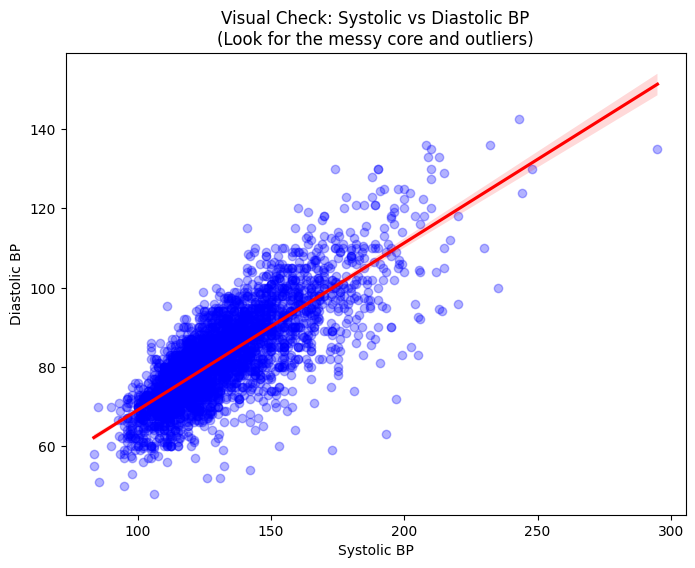

In [34]:
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df, 
    x='sysBP', 
    y='diaBP', 
    scatter_kws={'alpha':0.3, 'color': 'blue'}, # Alpha makes overlapping dots darker
    line_kws={'color': 'red'}
)
plt.title("Visual Check: Systolic vs Diastolic BP\n(Look for the messy core and outliers)")
plt.xlabel("Systolic BP")
plt.ylabel("Diastolic BP")
plt.show()